In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings('ignore')

In [ ]:
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

In [ ]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
print(f'trianing set shape: {train.shape}')
print(f'test set shape: {test.shape}')
train.head()

trianing set shape: (891, 12)
test set shape: (418, 11)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
print('missing values in the training set : ')
print(train.isnull().sum())
print('\n overall survival rate : ', train['Survived'].mean())

missing values in the training set : 
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

 overall survival rate :  0.3838383838383838


In [ ]:
print('missing values in the test set : ')
print(test.isnull().sum())

missing values in the test set : 
PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64


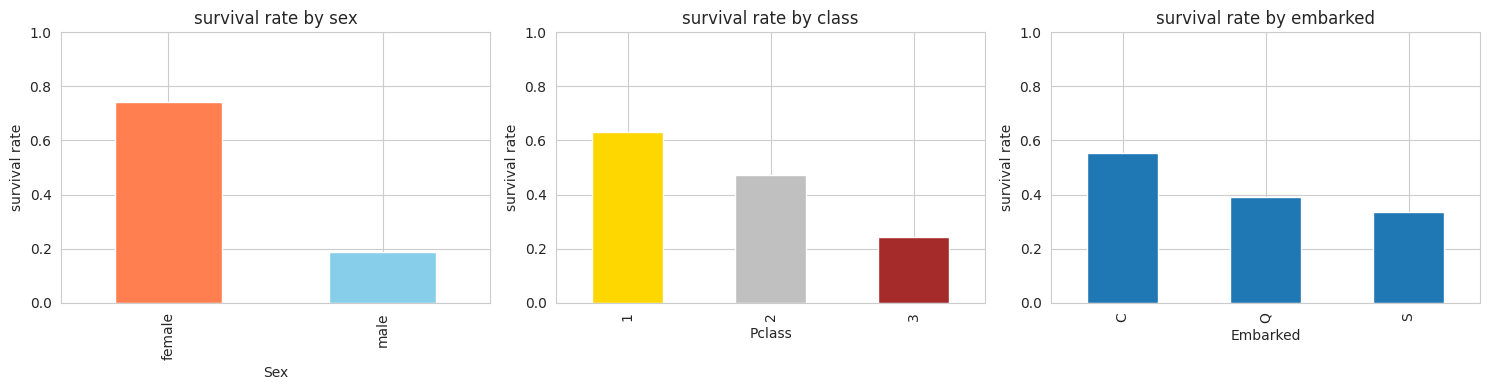

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
# by sex
train.groupby('Sex')['Survived'].mean().plot(kind = 'bar', ax = axes[0], color = ['coral', 'skyblue'])
axes[0].set_title('survival rate by sex')
axes[0].set_ylabel('survival rate')
axes[0].set_ylim(0, 1)

# by class
train.groupby('Pclass')['Survived'].mean().plot(kind = 'bar', ax = axes[1], color = ['gold', 'silver', 'brown'])
axes[1].set_title('survival rate by class')
axes[1].set_ylabel('survival rate')
axes[1].set_ylim(0, 1)

# by embarked
train.groupby('Embarked')['Survived'].mean().plot(kind = 'bar', ax = axes[2])
axes[2].set_title('survival rate by embarked')
axes[2].set_ylabel('survival rate')
axes[2].set_ylim(0, 1)

plt.tight_layout()
plt.show()

In [ ]:
def extract_title(name):
  "extract title from the passenger name"
  title = name.split(',')[1].split('.')[0].strip()
  # group rare titles
  if title in ('Lady, Countess, Capt, Col, Don, Dr, Major, Rev, Sir, Jonkheer, Dona'):
    return 'Rare'
  elif title in ('Mlle, Ms'):
    return 'Miss'
  elif title == 'Mme':
    return 'Mrs'
  return title

In [ ]:
def engineer_features(df):
  df = df.copy()
  df['Title'] = df['Name'].apply(extract_title)
  df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
  df['IsAlone'] = (df['FamilySize'] == 1).astype(int)
  df['Age'] = df['Age'].fillna(df['Age'].median())
  df['Fare'] = df['Fare'].fillna(df['Fare'].median())
  df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
  return df
train_fe = engineer_features(train)
test_fe = engineer_features(test)

print('new features created1')
print(train_fe[['Name', 'Title', 'FamilySize', 'IsAlone']].head())

new features created1
                                                Name Title  FamilySize  \
0                            Braund, Mr. Owen Harris    Mr           2   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...   Mrs           2   
2                             Heikkinen, Miss. Laina  Miss           1   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)   Mrs           2   
4                           Allen, Mr. William Henry    Mr           1   

   IsAlone  
0        0  
1        0  
2        1  
3        0  
4        1  


In [ ]:
train_fe.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,FamilySize,IsAlone
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Mr,2,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Mrs,2,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Miss,1,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Mrs,2,0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Mr,1,1


In [ ]:
feature_columns = ['Pclass', 'Sex', 'Age', 'Fare', 'Embarked', 'FamilySize', 'IsAlone', 'Title']

# combining test and train for consistent encoding
combined = pd.concat([train_fe[feature_columns], test_fe[feature_columns]], axis = 0)

# convert categorical variable into numeric(one - hot encoding)
combined_encoded = pd.get_dummies(combined, columns = ['Sex', 'Embarked', 'Title'], drop_first = True)

In [ ]:
combined.head()

,Pclass,Sex,Age,Fare,Embarked,FamilySize,IsAlone,Title
0,3,male,22.0,7.2500,S,2,0,Mr
1,1,female,38.0,71.2833,C,2,0,Mrs
2,3,female,26.0,7.9250,S,1,1,Miss
3,1,female,35.0,53.1000,S,2,0,Mrs
4,3,male,35.0,8.0500,S,1,1,Mr


In [ ]:
combined_encoded.head()

,Pclass,Age,Fare,FamilySize,IsAlone,Sex_male,Embarked_Q,Embarked_S,Title_Miss,Title_Mr,Title_Mrs,Title_Rare,Title_the Countess
0,3,22.0,7.2500,2,0,True,False,True,False,True,False,False,False
1,1,38.0,71.2833,2,0,False,False,False,False,False,True,False,False
2,3,26.0,7.9250,1,1,False,False,True,True,False,False,False,False
3,1,35.0,53.1000,2,0,False,False,True,False,False,True,False,False
4,3,35.0,8.0500,1,1,True,False,True,False,True,False,False,False


In [ ]:
x_train = combined_encoded[:len(train_fe)]
x_test = combined_encoded[len(train_fe):]
y_train = train_fe['Survived']

In [ ]:
print(f'training features shape : {x_train.shape}')
print(f'test features shape : {x_test.shape}')
print(f'features used : {list(x_train.columns)}')

training features shape : (891, 13)
test features shape : (418, 13)
features used : ['Pclass', 'Age', 'Fare', 'FamilySize', 'IsAlone', 'Sex_male', 'Embarked_Q', 'Embarked_S', 'Title_Miss', 'Title_Mr', 'Title_Mrs', 'Title_Rare', 'Title_the Countess']


In [ ]:
lr_model = LogisticRegression(max_iter = 1000, random_state = 42)
lr_cv_scores = cross_val_score(lr_model, x_train, y_train, cv = 5, scoring = 'accuracy')
print('Logistic Regression cross validation scores : ')
print(f'individual folds : {lr_cv_scores}')
print(f'mean cv accuracy : {lr_cv_scores.mean():.4f} (+/- {lr_cv_scores.std():.4f})')
lr_model.fit(x_train, y_train)
print('logistic regression model trained !!!!!!!!')

Logistic Regression cross validation scores : 
individual folds : [0.81564246 0.82022472 0.80898876 0.79775281 0.84831461]
mean cv accuracy : 0.8182 (+/- 0.0169)
logistic regression model trained !!!!!!!!


In [ ]:
lr_predicitons = lr_model.predict(x_test)
print(f'predictions made : {len(lr_predicitons)}')
print(f'predicted survival rate : {lr_predicitons.mean():.2%}')

predictions made : 418
predicted survival rate : 39.23%


In [ ]:
lr_submission = pd.DataFrame({
    'PassengerId' : test_fe['PassengerId'],
    'Survived' : lr_predicitons
})
lr_submission.to_csv('lr_submission.csv', index = False)

In [ ]:
dt_model = DecisionTreeClassifier(
    max_depth = 15,
    min_samples_split = 20,
    min_samples_leaf = 10,
    random_state = 42
)

dt_cv_scores = cross_val_score(dt_model, x_train, y_train, cv = 5, scoring = 'accuracy')
print('Decision tree cross validation scores : ')
print(f'individual folds : {dt_cv_scores}')
print(f'mean cv accuracy : {dt_cv_scores.mean():.4f} (+/- {dt_cv_scores.std():.4f})')
dt_model.fit(x_train, y_train)
print('Decision tree model trained !!!!!!!!')

Decision tree cross validation scores : 
individual folds : [0.79888268 0.76404494 0.86516854 0.79213483 0.83146067]
mean cv accuracy : 0.8103 (+/- 0.0348)
Decision tree model trained !!!!!!!!


In [ ]:
dt_predicitons = dt_model.predict(x_test)
print(f'predictions made : {len(dt_predicitons)}')
print(f'predicted survival rate : {dt_predicitons.mean():.2%}')

predictions made : 418
predicted survival rate : 37.80%


In [ ]:
dt_submission = pd.DataFrame({
    'PassengerId' : test_fe['PassengerId'],
    'Survived' : dt_predicitons
})
dt_submission.to_csv('dt_submission.csv', index = False)

In [ ]:
rf_model = RandomForestClassifier(
    n_estimators = 100,
    max_depth = 7,
    min_samples_split = 10,
    min_samples_leaf = 4,
    random_state = 42
)

rf_cv_scores = cross_val_score(rf_model, x_train, y_train, cv = 5, scoring = 'accuracy')
print('Random Forest validation scores : ')
print(f'individual folds : {rf_cv_scores}')
print(f'mean cv accuracy : {rf_cv_scores.mean():.4f} (+/- {rf_cv_scores.std():.4f})')
rf_model.fit(x_train, y_train)
print('random forest model trained !!!!!!!!')

Random Forest validation scores : 
individual folds : [0.82122905 0.81460674 0.84269663 0.80337079 0.86516854]
mean cv accuracy : 0.8294 (+/- 0.0220)
random forest model trained !!!!!!!!


In [ ]:
rf_predicitons = rf_model.predict(x_test)
print(f'predictions made : {len(rf_predicitons)}')
print(f'predicted survival rate : {rf_predicitons.mean():.2%}')

predictions made : 418
predicted survival rate : 36.84%


In [ ]:
rf_submission = pd.DataFrame({
    'PassengerId' : test_fe['PassengerId'],
    'Survived' : rf_predicitons
})
rf_submission.to_csv('rf_submission.csv', index = False)